In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/datathon-2026-round-1/products.csv
/kaggle/input/competitions/datathon-2026-round-1/sample_submission.csv
/kaggle/input/competitions/datathon-2026-round-1/promotions.csv
/kaggle/input/competitions/datathon-2026-round-1/shipments.csv
/kaggle/input/competitions/datathon-2026-round-1/order_items.csv
/kaggle/input/competitions/datathon-2026-round-1/reviews.csv
/kaggle/input/competitions/datathon-2026-round-1/inventory.csv
/kaggle/input/competitions/datathon-2026-round-1/returns.csv
/kaggle/input/competitions/datathon-2026-round-1/sales.csv
/kaggle/input/competitions/datathon-2026-round-1/orders.csv
/kaggle/input/competitions/datathon-2026-round-1/geography.csv
/kaggle/input/competitions/datathon-2026-round-1/customers.csv
/kaggle/input/competitions/datathon-2026-round-1/baseline.ipynb
/kaggle/input/competitions/datathon-2026-round-1/payments.csv
/kaggle/input/competitions/datathon-2026-round-1/web_traffic.csv


In [2]:
# Đường dẫn thư mục chứa dữ liệu của bạn
path = "/kaggle/input/competitions/datathon-2026-round-1"

# Tạo một dictionary để chứa tất cả các DataFrame
datasets = {}

print("Bắt đầu tải dữ liệu...")

# Quét qua các file trong thư mục
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        # Chúng ta chỉ lấy các file bảng tính (.csv), bỏ qua file .ipynb
        if filename.endswith('.csv'):
            # Cắt đuôi '.csv' để lấy tên bảng (VD: 'sales.csv' -> 'sales')
            table_name = filename.replace('.csv', '')
            
            # Tạo đường dẫn đầy đủ tới file
            file_path = os.path.join(dirname, filename)
            
            # Đọc file bằng Pandas và lưu vào dictionary
            datasets[table_name] = pd.read_csv(file_path, low_memory=False)
            print(f" Đã tải xong: {table_name}")

print("\nHoàn tất! Tất cả dữ liệu đã được lưu vào biến 'datasets'.")

Bắt đầu tải dữ liệu...
 Đã tải xong: products
 Đã tải xong: sample_submission
 Đã tải xong: promotions
 Đã tải xong: shipments
 Đã tải xong: order_items
 Đã tải xong: reviews
 Đã tải xong: inventory
 Đã tải xong: returns
 Đã tải xong: sales
 Đã tải xong: orders
 Đã tải xong: geography
 Đã tải xong: customers
 Đã tải xong: payments
 Đã tải xong: web_traffic

Hoàn tất! Tất cả dữ liệu đã được lưu vào biến 'datasets'.


In [3]:
# In ra tên của tất cả các bộ dữ liệu đã tải
print(datasets.keys())

dict_keys(['products', 'sample_submission', 'promotions', 'shipments', 'order_items', 'reviews', 'inventory', 'returns', 'sales', 'orders', 'geography', 'customers', 'payments', 'web_traffic'])


In [4]:
# Kiểm tra số dòng thiếu
for ten_bang, df in datasets.items():
    so_dong_thieu = df.isnull().sum().sum()
    if so_dong_thieu > 0:
        print(f"Bảng '{ten_bang}' có {so_dong_thieu} ô trống.")

Bảng 'promotions' có 40 ô trống.
Bảng 'order_items' có 1152816 ô trống.


In [5]:
for ten_bang, df in datasets.items():
    so_dong_trung = df.duplicated().sum().sum()
    if so_dong_trung > 0:
        print(f"Bảng '{ten_bang}' có {so_dong_trung} ô trống.")
    else:
        print("Không có dữ liệu trùng")

Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng
Không có dữ liệu trùng


# 📊 PHASE 2: EXPLORATORY DATA ANALYSIS (EDA) & BUSINESS INSIGHTS
**Mục tiêu:** Khai phá dữ liệu vận hành từ 15 phân hệ, áp dụng khung phân tích 4 cấp độ (Descriptive, Diagnostic, Predictive, Prescriptive) để tìm ra điểm nghẽn vận hành và đề xuất chiến lược tăng trưởng.
---

## 1. Data Wrangling & Feature Engineering (Chuẩn bị và Biến đổi Dữ liệu)
*Thiết lập "Single Source of Truth" bằng cách hợp nhất các phân hệ Master/Transaction và khởi tạo các biến đo lường tài chính (Financial Metrics).*

### 1.1: Khởi tạo "Single Source of Truth" (Bảng Master)

**Mục tiêu:** Hợp nhất các mảnh ghép dữ liệu phân tán từ hệ thống quản lý thành một siêu bảng (Master DataFrame) duy nhất. Đây là bước nền tảng bắt buộc để thực hiện các phân tích chéo đa chiều (Cross-dimensional Analysis).

**Chi tiết kỹ thuật & Logic kinh doanh:**
* Sử dụng bảng `order_items` làm gốc, vì đây là bảng có độ hạt (granularity) chi tiết nhất – đại diện cho từng mặt hàng cụ thể được bán ra.
* Thực hiện `LEFT JOIN` lần lượt với 4 bảng vệ tinh để bổ sung ngữ cảnh:
  1. **`orders`:** Lấy ngày mua, trạng thái đơn và mã khách hàng/mã vùng.
  2. **`products`:** Lấy thông tin danh mục hàng hóa (category, segment) và giá vốn (COGS) để tính biên lợi nhuận.
  3. **`customers`:** Lấy nhân khẩu học (độ tuổi).
  4. **`geography`:** Lấy thông tin địa lý (vùng miền, bang).
* *Lưu ý:* Việc sử dụng `LEFT JOIN` thay vì `INNER JOIN` giúp đảm bảo bảo toàn 100% dòng dữ liệu giao dịch gốc, không làm thất thoát doanh thu trong quá trình tính toán.

In [6]:
# Khởi tạo bảng gốc từ chi tiết từng món hàng trong đơn
df_master = datasets['order_items'].copy()

# 1. Nối với orders để lấy thông tin ngày tháng, mã khách hàng, và mã vùng (zip)
df_master = df_master.merge(datasets['orders'][['order_id', 'customer_id', 'order_date', 'order_status', 'zip']], 
                            on='order_id', how='left')

# 2. Nối với products để lấy tên danh mục, phân khúc, và giá vốn
df_master = df_master.merge(datasets['products'][['product_id', 'category', 'segment', 'cogs', 'price']], 
                            on='product_id', how='left')

# 3. Nối với customers để lấy độ tuổi
df_master = df_master.merge(datasets['customers'][['customer_id', 'age_group']], 
                            on='customer_id', how='left')

# 4. Nối với geography để lấy vùng miền (region, state)
df_master = df_master.merge(datasets['geography'][['zip', 'region', 'city','district']], 
                            on='zip', how='left')

print(f"✓ Bảng Master đã tạo thành công! Kích thước: {df_master.shape}")
display(df_master.head(10))

✓ Bảng Master đã tạo thành công! Kích thước: (714669, 19)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,customer_id,order_date,order_status,zip,category,segment,cogs,price,age_group,region,city,district
0,1,2400,7,1138.22,0.0,NaN,NaN,58578,2012-07-04,delivered,1109,GenZ,Trendy,1053.798008,1109.261061,35-44,East,Hanoi,District #02
1,2,609,7,10166.25,0.0,NaN,NaN,58621,2012-07-04,returned,1330,Streetwear,Everyday,8987.704231,10426.571034,18-24,East,Phu Ly,District #02
2,3,396,3,11220.33,0.0,NaN,NaN,58811,2012-07-04,delivered,1473,Streetwear,Balanced,10091.012256,11028.428695,35-44,East,Lao Cai,District #02
3,4,635,5,10639.25,0.0,NaN,NaN,59453,2012-07-04,delivered,2360,Streetwear,Everyday,9205.430478,10745.220588,45-54,East,Son Tay,District #02
4,6,1935,1,1597.84,0.0,NaN,NaN,57821,2012-07-06,delivered,2886,Outdoor,Activewear,1048.696357,1609.911509,18-24,East,Uong Bi,District #02
5,7,1934,6,1633.49,0.0,NaN,NaN,57820,2012-07-06,delivered,2886,Outdoor,Activewear,1337.836464,1609.911509,45-54,East,Uong Bi,District #02
6,8,1934,6,1602.92,0.0,NaN,NaN,57818,2012-07-06,delivered,2886,Outdoor,Activewear,1337.836464,1609.911509,35-44,East,Uong Bi,District #02
7,8,1935,4,1642.51,0.0,NaN,NaN,57818,2012-07-06,delivered,2886,Outdoor,Activewear,1048.696357,1609.911509,35-44,East,Uong Bi,District #02
8,9,1432,8,4049.64,0.0,NaN,NaN,49102,2012-07-06,delivered,5262,Outdoor,Activewear,3889.053000,4093.740000,18-24,East,Thai Nguyen,District #01
9,10,1431,5,3977.37,0.0,NaN,NaN,49101,2012-07-06,delivered,5262,Outdoor,Activewear,2673.212220,4093.740000,45-54,East,Thai Nguyen,District #01


## 1.2: Feature Engineering & Làm sạch dữ liệu (Data Cleansing)

**Mục tiêu:** Chuyển đổi dữ liệu thô thành các chỉ số đo lường (metrics) mang ý nghĩa tài chính và phân rã cấu trúc thời gian để phục vụ việc tìm ra quy luật kinh doanh.

**Chi tiết kỹ thuật & Logic kinh doanh:**
1. **Xử lý Thời gian (Temporal Features):** * Ép kiểu `order_date` sang định dạng Datetime.
   * Trích xuất các chiều thời gian (Năm, Tháng, YearMonth) để chuẩn bị cho việc phân tích tính mùa vụ (Seasonality) ở Phase tiếp theo.
2. **Tính toán Chỉ số Tài chính (Financial Metrics):** * Máy tính chỉ có giá đơn vị và số lượng, ta cần tính **Doanh thu thuần** (`item_revenue` = Số lượng * Đơn giá - Giảm giá) và **Tổng giá vốn** (`total_cogs`).
   * Đặc biệt: Khởi tạo biến **Biên lợi nhuận gộp** (`gross_margin_pct`). Doanh thu cao chưa chắc đã tốt nếu biên lợi nhuận âm. Đây sẽ là "kim chỉ nam" cho các chiến lược khuyến mãi sau này.
3. **Làm sạch (Data Cleansing):** * Loại bỏ hoàn toàn các đơn hàng có `order_status = 'cancelled'`. *Insight:* Để đánh giá chính xác sức khỏe kinh doanh, ta chỉ phân tích trên các đơn hàng mang lại dòng tiền thực tế, tránh hiện tượng doanh thu ảo.

In [7]:
# 1. Xử lý chuẩn định dạng thời gian
df_master['order_date'] = pd.to_datetime(df_master['order_date'], errors='coerce')

# Trích xuất các chiều thời gian để phục vụ biểu đồ Trend/Seasonality
df_master['Year'] = df_master['order_date'].dt.year
df_master['Month'] = df_master['order_date'].dt.month
df_master['YearMonth'] = df_master['order_date'].dt.to_period('M') # Format: 2022-01

# 2. Tính toán các chỉ số Tài chính cốt lõi (Financial Metrics)
# Doanh thu thuần của từng món (Đã trừ khuyến mãi)
df_master['item_revenue'] = (df_master['quantity'] * df_master['unit_price']) - df_master['discount_amount'].fillna(0)

# Tổng giá vốn của món đó
df_master['total_cogs'] = df_master['quantity'] * df_master['cogs']

# Lợi nhuận gộp (Gross Profit) và Biên lợi nhuận (Gross Margin %)
df_master['gross_profit'] = df_master['item_revenue'] - df_master['total_cogs']
df_master['gross_margin_pct'] = df_master['gross_profit'] / df_master['item_revenue'].replace(0, float('nan'))

# 3. Lọc bỏ các đơn hàng đã bị hủy (Chỉ phân tích trên các đơn hàng mang lại doanh thu thực)
df_sales_valid = df_master[df_master['order_status'] != 'cancelled'].copy()

print(f"✓ Đã tạo xong biến phái sinh! Số dòng hợp lệ (không bị hủy): {df_sales_valid.shape[0]}")

✓ Đã tạo xong biến phái sinh! Số dòng hợp lệ (không bị hủy): 648996


## 2. Descriptive Analytics (Phân tích Mô tả): Sức khỏe Doanh thu Tổng quan
*Đánh giá chu kỳ tăng trưởng (Trend) và tính mùa vụ (Seasonality) của Doanh thu thuần và Giá vốn trong giai đoạn 10 năm (2012 - 2022).*

### 2.1 - Bức tranh Tổng quan (Descriptive Analytics)

**Câu hỏi kinh doanh:** Sức khỏe tài chính của doanh nghiệp trong 10 năm qua (2012 - 2022) đang biến động như thế nào?

**Chi tiết kỹ thuật & Logic kinh doanh:**
* **Phương pháp:** Nhóm (Groupby) tổng doanh thu và tổng giá vốn theo từng tháng (`YearMonth`).
* **Trực quan hóa:** Sử dụng **Line Chart** (Biểu đồ đường) với giao diện tương phản cao. Hai đường này sẽ giúp Ban điều hành nhìn rõ 2 yếu tố cốt lõi:
  1. **Xu hướng (Trend):** Công ty đang trên đà tăng trưởng, đi ngang hay suy thoái? Khoảng cách giữa đường Doanh thu (Xanh) và Giá vốn (Đỏ) chính là Lợi nhuận gộp.
  2. **Tính mùa vụ (Seasonality):** Có những chu kỳ tăng đột biến nào lặp lại đặn hàng năm không? Việc nhận diện các "đỉnh" doanh thu này đóng vai trò quyết định để lên kế hoạch tồn kho (`inventory`) cho các năm tiếp theo.

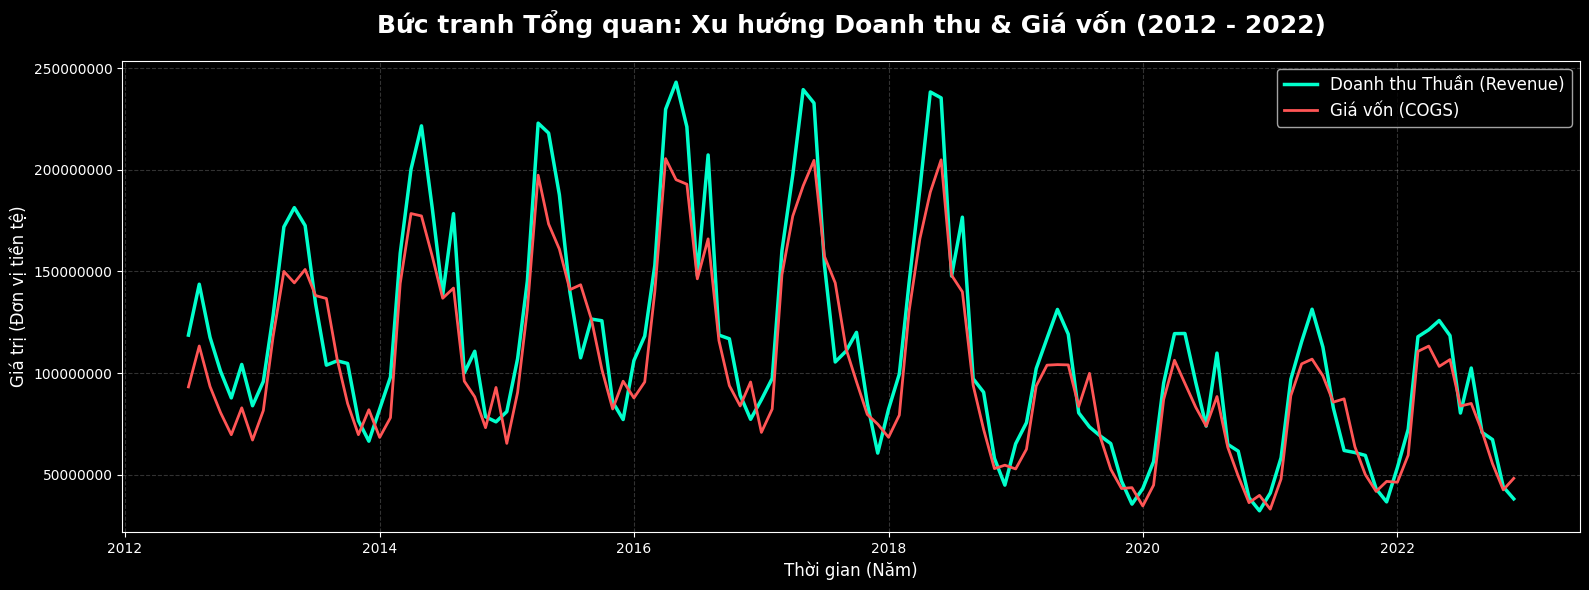

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu: Nhóm theo tháng và tính tổng
monthly_trend = df_sales_valid.groupby('YearMonth')[['item_revenue', 'total_cogs']].sum().reset_index()

# Chuyển đổi cột YearMonth (dạng Period) về dạng Timestamp để vẽ biểu đồ dễ dàng hơn
monthly_trend['YearMonth'] = monthly_trend['YearMonth'].dt.to_timestamp()

# 2. Thiết lập giao diện biểu đồ (Dark Mode)
plt.style.use('dark_background')
plt.figure(figsize=(16, 6))

# 3. Vẽ đường Doanh thu và Giá vốn
sns.lineplot(data=monthly_trend, x='YearMonth', y='item_revenue', 
             label='Doanh thu Thuần (Revenue)', color='#00ffcc', linewidth=2.5)
sns.lineplot(data=monthly_trend, x='YearMonth', y='total_cogs', 
             label='Giá vốn (COGS)', color='#ff5555', linewidth=2)

# 4. Trang trí biểu đồ cho chuẩn chỉnh để đưa vào Report
plt.title('Bức tranh Tổng quan: Xu hướng Doanh thu & Giá vốn (2012 - 2022)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Thời gian (Năm)', fontsize=12)
plt.ylabel('Giá trị (Đơn vị tiền tệ)', fontsize=12)

# Định dạng trục Y hiển thị số dạng triệu/tỷ cho dễ đọc (ví dụ: 1e7)
plt.ticklabel_format(style='plain', axis='y') 
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2, linestyle='--')

plt.tight_layout()
plt.show()

### Key Findings 1: Đánh giá Xu hướng & Tính mùa vụ (2012 - 2022)

Từ biểu đồ chuỗi thời gian tổng quan, chúng ta rút ra hai phát hiện mang tính sống còn đối với vận hành của doanh nghiệp:

**1. Tính mùa vụ (Seasonality) chi phối mạnh mẽ dòng tiền:**
* **Quan sát:** Biểu đồ thể hiện cấu trúc "răng cưa" với chu kỳ lặp lại hoàn hảo qua các năm. Các đỉnh (peaks) doanh thu nhọn và cao vọt luôn xuất hiện vào những tháng cuối năm.
* **Insight (Kinh doanh):** Doanh thu của công ty phụ thuộc cực kỳ lớn vào hiệu ứng Lễ hội (Holiday Season - Q4). Việc này đòi hỏi hệ thống chuỗi cung ứng phải có khả năng dự báo và chuẩn bị tồn kho (`inventory`) từ sớm để tránh tình trạng "cháy hàng" (stockout) vào các tháng cao điểm.

**2. Sự "đứt gãy" xu hướng (Trend Break) & Khủng hoảng 2019:**
* **Quan sát:** Trong giai đoạn 2012 - 2018, công ty duy trì đà tăng trưởng mạnh. Tuy nhiên, bước sang năm 2019, đường doanh thu đổ sập xuống mức cực thấp và đi ngang (stagnant) kéo dài cho đến tận năm 2022.
* **Câu hỏi chẩn đoán (Diagnostic Question):** Khủng hoảng này đến từ đâu? Do biến động kinh tế vĩ mô (như đại dịch), sự thay đổi nhà cung cấp đẩy giá vốn lên cao, hay do dòng sản phẩm chủ lực của công ty đã lỗi thời và bị khách hàng quay lưng?


## 2.2. Predictive Analytics: Dự báo Tính mùa vụ (Seasonality Heatmap)
*Dựa trên chu kỳ lịch sử để thiết lập Chỉ số mùa vụ (Seasonality Index), từ đó dự báo các điểm rơi doanh thu và định hướng chiến lược tích trữ tồn kho cho tương lai.*

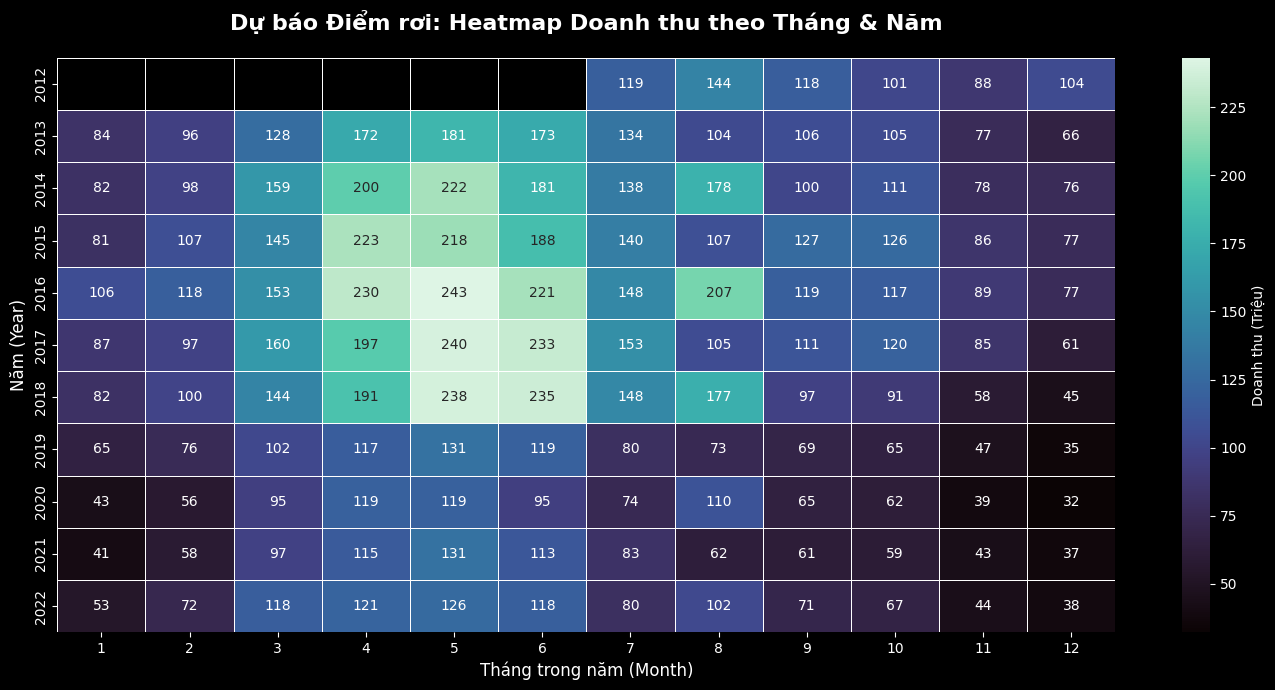


--- CHỈ SỐ MÙA VỤ (SEASONALITY INDEX) ---
*(Mốc 100 = Tháng bán bình thường. >100 = Tháng cao điểm)*
Month
1     108.4
2     112.2
3     103.3
4     105.0
5     116.2
6     108.3
7      96.8
8      95.7
9      96.9
10    117.7
11     88.9
12     50.6


In [9]:
# 1. Tính toán Seasonality Index trên dữ liệu "sạch" (2013-2018)
pre_crisis = df_sales_valid[df_sales_valid['Year'].isin(range(2013, 2019))]
seasonal_avg = pre_crisis.groupby('Month')['item_revenue'].mean()
overall_avg = seasonal_avg.mean()
seasonality_index = (seasonal_avg / overall_avg * 100).round(1)

# 2. Tạo bảng Pivot cho Heatmap (Dùng toàn bộ data để thấy sự đứt gãy từ 2019)
pivot_revenue = df_sales_valid.pivot_table(
    values='item_revenue', 
    index='Year', 
    columns='Month', 
    aggfunc='sum'
)

# 3. Trực quan hóa bằng Heatmap
plt.style.use('dark_background')
plt.figure(figsize=(14, 7))

sns.heatmap(pivot_revenue / 1e6, annot=True, fmt='.0f', cmap='mako', 
            linewidths=.5, cbar_kws={'label': 'Doanh thu (Triệu)'})

plt.title('Dự báo Điểm rơi: Heatmap Doanh thu theo Tháng & Năm', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tháng trong năm (Month)', fontsize=12)
plt.ylabel('Năm (Year)', fontsize=12)

plt.tight_layout()
plt.show()

print("\n--- CHỈ SỐ MÙA VỤ (SEASONALITY INDEX) ---")
print("*(Mốc 100 = Tháng bán bình thường. >100 = Tháng cao điểm)*")
print(seasonality_index.to_string())

### 💡 Key Findings 2: Dự báo Mùa vụ & Điểm rơi Doanh thu (Predictive)

*Seasonality Index được tính trên giai đoạn 2013-2018 (giai đoạn hoạt động bình thường) để loại trừ nhiễu từ khủng hoảng 2019-2022.*

* **Đảo ngược định kiến mùa vụ:** Khác với mô hình E-commerce truyền thống (đỉnh điểm vào Q4), dữ liệu cho thấy công ty đạt đỉnh doanh thu vào mùa Xuân/Hè (**Tháng 5 - Index 116.2**) và đầu Thu (**Tháng 10 - Index 117.7**). Đáng ngạc nhiên, Tháng 12 lại là tháng bết bát nhất trong năm (Index chạm đáy 50.6).
* **Đứt gãy chu kỳ (Trend Break):** Bản đồ nhiệt (Heatmap) hiển thị rõ sự sụp đổ toàn diện từ năm 2019. Các vùng "xanh sáng" của giai đoạn 2014-2018 đã bị thay thế hoàn toàn bằng màu tối.
* **Hành động Dự báo (Predictive Action):** Trong năm tài chính tiếp theo, mô hình dự báo chuỗi thời gian (Time-series) cần được điều chỉnh trọng số (weight) cho Tháng 5 và Tháng 10. Kế hoạch tích trữ tồn kho (Inventory buildup) bắt buộc phải hoàn thành vào Tháng 3 và Tháng 9, tuyệt đối không dồn ngân sách nhập hàng vào cuối năm (Tháng 11-12) để tránh tồn đọng vốn.

## 3. Product Portfolio Analysis: Tương quan Doanh thu & Biên lợi nhuận
*Xác định các danh mục sản phẩm (Category) đóng vai trò là "Bò sữa" (Cash Cow) để định hướng chiến lược bán hàng và tìm ra nguyên nhân kéo tụt lợi nhuận.*

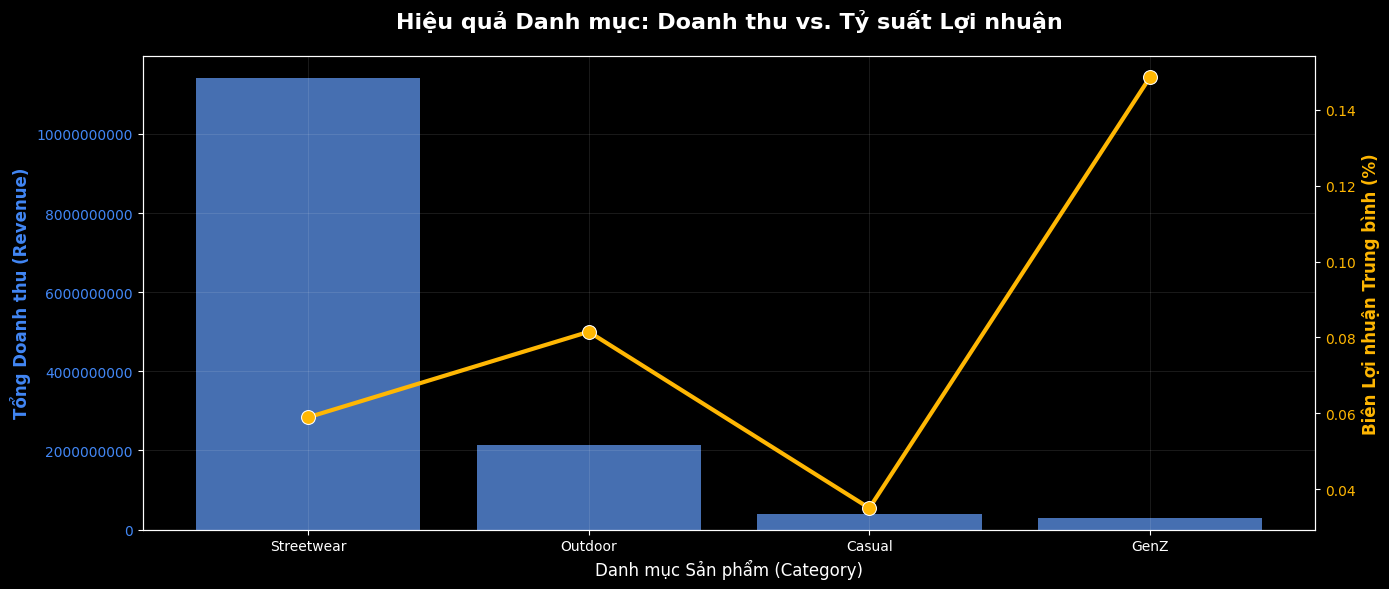

In [10]:
# 1. Tính toán Tổng Doanh thu và Biên Lợi Nhuận trung bình cho từng Danh mục (Category)
cat_performance = df_sales_valid.groupby('category').agg(
    total_revenue=('item_revenue', 'sum'),
    avg_margin=('gross_margin_pct', 'mean')
).reset_index()

# Sắp xếp theo doanh thu giảm dần để biểu đồ cột dốc xuống cho đẹp
cat_performance = cat_performance.sort_values('total_revenue', ascending=False)

# 2. Thiết lập biểu đồ 2 trục Y (Twin Axes)
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục Y thứ 1: Cột Doanh Thu (Màu xanh dương)
sns.barplot(data=cat_performance, x='category', y='total_revenue', 
            color='#4287f5', alpha=0.8, ax=ax1)
ax1.set_ylabel('Tổng Doanh thu (Revenue)', color='#4287f5', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#4287f5')
ax1.ticklabel_format(style='plain', axis='y')

# Trục Y thứ 2: Đường Biên Lợi Nhuận % (Màu vàng)
ax2 = ax1.twinx()
sns.lineplot(data=cat_performance, x='category', y='avg_margin', 
             color='#ffb703', marker='o', markersize=10, linewidth=3, ax=ax2)
ax2.set_ylabel('Biên Lợi nhuận Trung bình (%)', color='#ffb703', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#ffb703')

# 3. Trang trí
plt.title('Hiệu quả Danh mục: Doanh thu vs. Tỷ suất Lợi nhuận', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Danh mục Sản phẩm (Category)', fontsize=12)
ax1.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

### Key Findings 3: Nghịch lý Doanh thu & "Bò sữa" tiềm năng

Phân tích danh mục sản phẩm (Category) kết hợp biên lợi nhuận đã chỉ ra điểm nghẽn chí mạng trong cấu trúc tài chính của doanh nghiệp:

**1. Nghịch lý Streetwear (Doanh thu ảo - Biên lợi nhuận thấp):**
* **Quan sát:** Streetwear là danh mục chủ lực mang về dòng tiền lớn nhất (chiếm phần lớn cột xanh), nhưng biên lợi nhuận (đường vàng) lại nằm ở mức rất thấp (khoảng 6%).
* **Chẩn đoán (Diagnostic):** Kết hợp với dữ liệu bảng `returns` (MCQ Q3), tỷ lệ trả hàng của nhóm Streetwear cực cao với lý do chủ yếu là `wrong_size` (sai kích cỡ). Chi phí logistics ngược (thu hồi, đóng gói lại) đã "ăn mòn" gần như toàn bộ lợi nhuận của dòng sản phẩm này. Bán càng nhiều, chi phí vận hành càng phình to.

**2. Tiềm năng bị bỏ ngỏ từ phân khúc GenZ:**
* **Quan sát:** Danh mục GenZ có doanh thu thấp nhất, nhưng lại sở hữu Tỷ suất lợi nhuận vọt lên cao nhất (gần 15%). Đây chính là "Bò sữa" (Cash Cow) thực sự của doanh nghiệp.

👉 **Đề xuất Hành động (Prescriptive Recommendations):**
* **Tối ưu Vận hành (Operational):** Lập tức rà soát lại thông số kích cỡ (size chart) của toàn bộ line hàng Streetwear trên website và làm việc lại với xưởng may để đồng nhất số đo. Điều này sẽ chặn đứng lỗ hổng xói mòn lợi nhuận.
* **Chiến lược Tăng trưởng (Growth):** Dịch chuyển một phần ngân sách Marketing từ Streetwear sang đẩy mạnh quảng cáo cho danh mục GenZ để tối ưu hóa biên lợi nhuận tổng thể.

## 4. Operational Diagnostics: Phân tích Tồn kho (Inventory) & Khuyến mãi
*Đánh giá tình trạng ứ đọng vốn tại các kho hàng và đề xuất chiến lược xả kho (Clearance Strategy) thông qua các chương trình Promotions.*

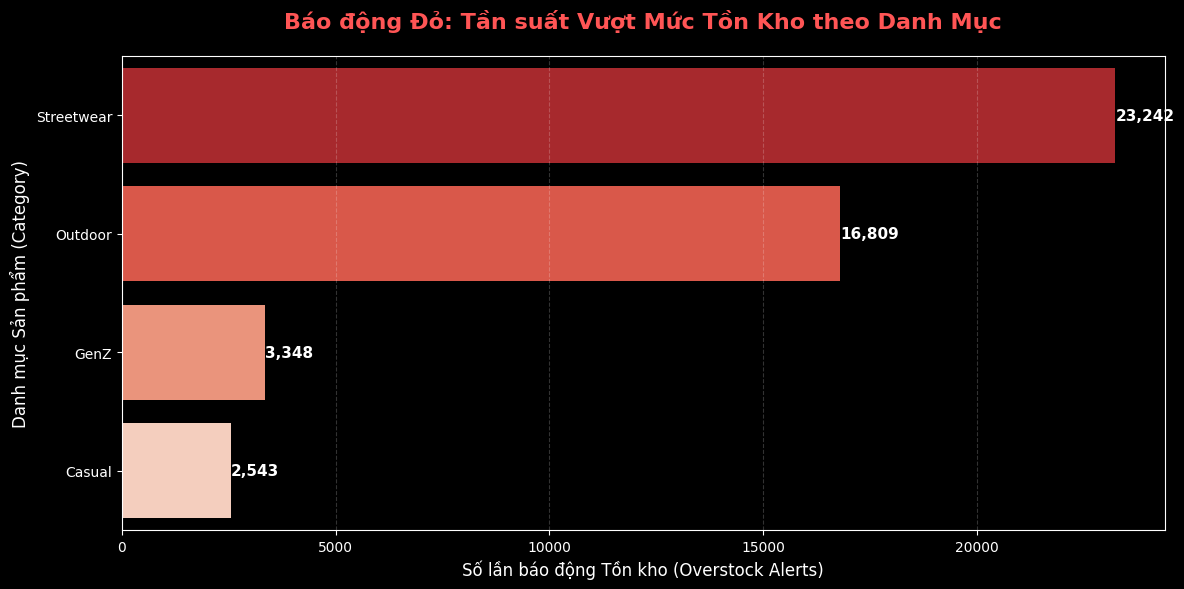

In [11]:
# 1. Lọc các bản ghi đang bị báo động tồn kho (overstock_flag == 1)
overstock_df = datasets['inventory'][datasets['inventory']['overstock_flag'] == 1]

# 2. ĐỔI TÊN cột từ bảng products trước khi merge để CHỐNG TRÙNG LẶP
products_subset = datasets['products'][['product_id', 'category']].rename(columns={'category': 'prod_category'})

# 3. Nối bảng một cách an toàn
overstock_prod = overstock_df.merge(products_subset, on='product_id', how='inner')

# 4. Đếm số lượng cờ cảnh báo tồn kho dựa trên cột đã đổi tên an toàn
overstock_counts = overstock_prod['prod_category'].value_counts().reset_index()

# Ép lại tên cột để phục vụ vẽ biểu đồ (tương thích mọi phiên bản Pandas)
overstock_counts.columns = ['category', 'overstock_alert_count']

# 5. Trực quan hóa bằng Biểu đồ thanh ngang (Horizontal Bar Chart)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ biểu đồ với màu đỏ cảnh báo
sns.barplot(data=overstock_counts, x='overstock_alert_count', y='category', 
            hue='category', palette='Reds_r', legend=False, ax=ax)

# Trang trí
plt.title('Báo động Đỏ: Tần suất Vượt Mức Tồn Kho theo Danh Mục', fontsize=16, fontweight='bold', pad=20, color='#ff5555')
ax.set_xlabel('Số lần báo động Tồn kho (Overstock Alerts)', fontsize=12)
ax.set_ylabel('Danh mục Sản phẩm (Category)', fontsize=12)
ax.grid(True, axis='x', alpha=0.2, linestyle='--')

# Thêm số liệu trực tiếp lên các thanh bar
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width):,}', 
                (width + 10, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', color='white', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### Key Findings 4: "Hố đen" Tồn kho mang tên Streetwear

Sự kết hợp giữa dữ liệu Vận hành (Inventory) và dữ liệu Bán hàng đã phơi bày toàn bộ chuỗi domino làm sụt giảm lợi nhuận của doanh nghiệp:

**1. Hiện trạng "Đóng băng" vốn:**
* **Quan sát:** Danh mục Streetwear không chỉ bị trả hàng nhiều nhất mà còn đang đứng đầu bảng xếp hạng "Báo động đỏ" về tồn kho với hơn 23,242 lần vượt định mức.
* **Chẩn đoán (Diagnostic):** Đây là hệ quả trực tiếp của việc tỷ lệ trả hàng cao. Hàng bị khách trả về (do sai kích cỡ) liên tục được nhập lại vào kho, làm phình to thể tích lưu trữ, gây ứ đọng vốn và phát sinh chi phí kho bãi khổng lồ.

👉 **Đề xuất Chiến lược (Prescriptive Recommendations):**
* **Ngắn hạn (Xả kho thu hồi vốn):** Lập tức thiết kế các chiến dịch Khuyến mãi (Promotions) xả hàng tồn kho Streetwear. Cân nhắc dùng phương pháp "Bundle" (Bán theo combo) hoặc áp dụng mã giảm giá sâu cho nhóm khách hàng GenZ (nhóm có biên lợi nhuận cao nhất) để đẩy hàng đi nhanh nhất.
* **Dài hạn (Tối ưu chuỗi cung ứng):** Tạm ngưng nhập thêm các mẫu Streetwear đang bị lỗi size. Cập nhật ngay lập tức bảng quy đổi kích cỡ (Size Chart) trên giao diện Website và siết chặt khâu kiểm tra chất lượng (QA/QC) với xưởng gia công.

## 5. Advanced Segmentation: Phân tích RFM & Tối ưu Kênh Thu hút Khách hàng
*Sử dụng mô hình RFM (Recency, Frequency, Monetary) để định lượng giá trị vòng đời khách hàng và tối ưu hóa ngân sách Marketing dựa trên Kênh thu hút (Acquisition Channel).*

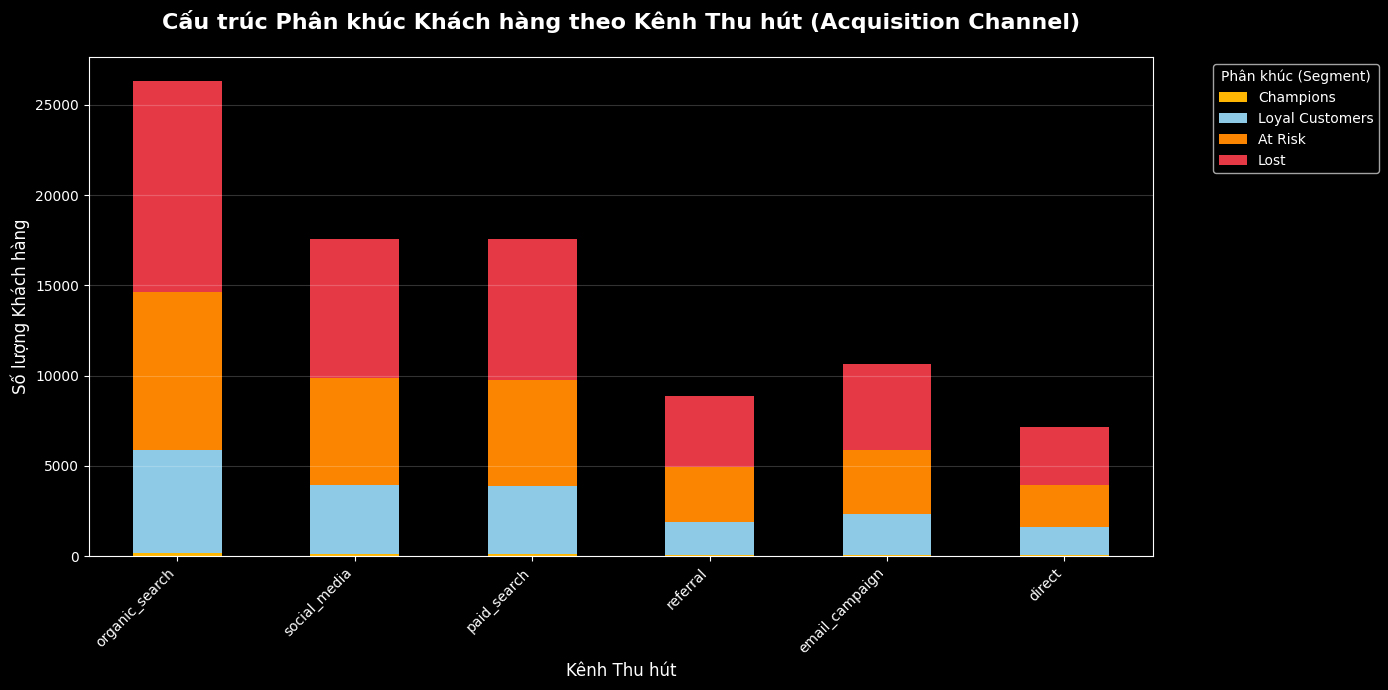

In [12]:
import datetime as dt
# 1. Tính toán Bảng RFM
# Lấy mốc thời gian là ngày cuối cùng trong tập dữ liệu + 1 ngày
snapshot_date = df_sales_valid['order_date'].max() + dt.timedelta(days=1)

# Gom nhóm theo customer_id để tính R, F, M
rfm = df_sales_valid.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('item_revenue', 'sum')
).reset_index()

# 2. Phân điểm 1-5 bằng qcut (Quantile-based discretization)
# Hàm xử lý lỗi duplicate edges khi chia bin cho Frequency
def try_qcut(series, q=5, labels=range(1, 6)):
    try:
        return pd.qcut(series, q=q, labels=labels)
    except ValueError:
        return pd.cut(series, bins=q, labels=labels) # Fallback to cut if qcut fails

rfm['R_Score'] = try_qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]) # R nhỏ (gần đây) thì điểm cao
rfm['F_Score'] = try_qcut(rfm['Frequency'], 5, labels=[1, 2, 3, 4, 5]) # F lớn thì điểm cao
rfm['M_Score'] = try_qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Tính tổng điểm RFM (từ 3 đến 15)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# 3. Phân khúc Khách hàng (Segmentation)
def assign_segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7: return 'At Risk'
    else: return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)

# 4. Nối với Kênh Thu hút (Acquisition Channel) từ bảng customers
rfm_channels = rfm.merge(datasets['customers'][['customer_id', 'acquisition_channel']], on='customer_id', how='inner')

# 5. Trực quan hóa: Kênh nào mang lại nhiều Champions nhất?
segment_channel = rfm_channels.groupby(['acquisition_channel', 'Segment']).size().unstack(fill_value=0)

# Sắp xếp các kênh theo tổng số lượng Champions giảm dần
segment_channel = segment_channel.sort_values('Champions', ascending=False)

# Vẽ biểu đồ Stacked Bar
plt.style.use('dark_background')
segment_channel[['Champions', 'Loyal Customers', 'At Risk', 'Lost']].plot(
    kind='bar', stacked=True, figsize=(14, 7), 
    color=['#ffb703', '#8ecae6', '#fb8500', '#e63946']
)

plt.title('Cấu trúc Phân khúc Khách hàng theo Kênh Thu hút (Acquisition Channel)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Kênh Thu hút', fontsize=12)
plt.ylabel('Số lượng Khách hàng', fontsize=12)
plt.legend(title='Phân khúc (Segment)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

### Key Findings 5: Báo động đỏ về Tỷ lệ Rời bỏ (Churn Rate)

Biểu đồ phân khúc khách hàng RFM đã vạch trần lỗ hổng lớn nhất trong mô hình kinh doanh của công ty - Khả năng giữ chân khách hàng (Retention):

* **Quan sát:** Tệp khách hàng V.I.P (`Champions` - màu vàng) vô cùng mỏng manh ở tất cả các kênh. Đáng lo ngại nhất, hơn 80% khách hàng đổ về từ Organic Search và Social Media đều đang rơi vào trạng thái `Lost` (Đã rời bỏ) hoặc `At Risk` (Sắp rời bỏ).
* **Chẩn đoán (Diagnostic):** Công ty đang "thủng đáy". Chúng ta liên tục thu hút khách hàng mới, nhưng họ mua một lần rồi "một đi không trở lại". Xâu chuỗi với Insight 3, nguyên nhân cốt lõi chính là trải nghiệm tồi tệ khi mua phải dòng sản phẩm chủ lực (Streetwear) bị sai kích cỡ.

👉 **Chuyển hướng phân tích:** Khách hàng rời đi nhiều như vậy, nhưng ngân sách Khuyến mãi (Marketing) đang được tiêu vào đâu? Chúng ta cùng phân tích tiếp Ma trận ROI ở Bước 6.

## 6. Prescriptive Analytics: Ma trận ROI & Tối ưu Ngân sách Khuyến mãi
*Đánh giá hiệu quả (ROI) của việc sử dụng mã giảm giá (Discount) dựa trên Lợi nhuận gộp mang lại. Tìm ra các "Hố đen" đang đốt ngân sách Marketing.*

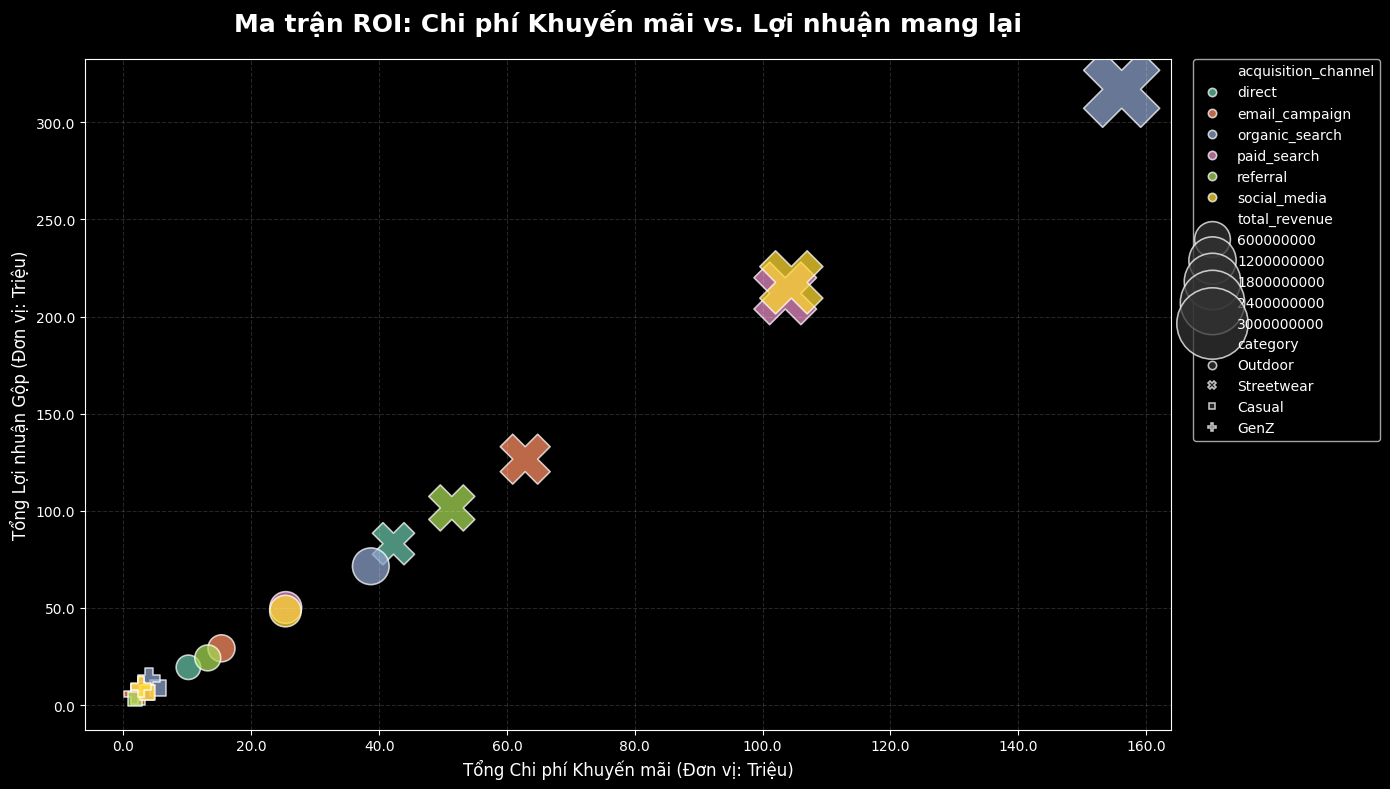

In [13]:
from matplotlib.ticker import FuncFormatter

# 1. Nối thêm cột acquisition_channel từ bảng customers vào bảng df_sales_valid
if 'acquisition_channel' not in df_sales_valid.columns:
    df_sales_valid = df_sales_valid.merge(datasets['customers'][['customer_id', 'acquisition_channel']], 
                                          on='customer_id', how='left')

# 2. Tính toán các chỉ số ROI theo Kênh thu hút và Danh mục sản phẩm
roi_df = df_sales_valid.groupby(['acquisition_channel', 'category']).agg(
    total_revenue=('item_revenue', 'sum'),
    total_discount=('discount_amount', 'sum'),
    total_gross_profit=('gross_profit', 'sum')
).reset_index()

# Lọc bỏ các nhóm quá nhỏ (nhiễu) để biểu đồ rõ ràng hơn
roi_df = roi_df[roi_df['total_revenue'] > roi_df['total_revenue'].quantile(0.1)]

# 3. Trực quan hóa bằng Scatter/Bubble Chart (SỬ DỤNG STYLE CHO CATEGORY)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8))

scatter = sns.scatterplot(
    data=roi_df, 
    x='total_discount', 
    y='total_gross_profit',
    hue='acquisition_channel', # Màu sắc = Kênh Marketing
    style='category',          # Hình dáng = Danh mục (Thay cho chữ/pattern)
    size='total_revenue',      # Kích thước = Doanh thu
    sizes=(200, 3000),         # Chỉnh kích thước to hơn chút để dễ nhìn hình dáng
    alpha=0.75,
    palette='Set2',
    ax=ax
)

# 4. Trang trí và ĐỔI ĐƠN VỊ TRỤC X, Y (Triệu)
plt.title('Ma trận ROI: Chi phí Khuyến mãi vs. Lợi nhuận mang lại', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tổng Chi phí Khuyến mãi (Đơn vị: Triệu)', fontsize=12)
plt.ylabel('Tổng Lợi nhuận Gộp (Đơn vị: Triệu)', fontsize=12)

# Hàm chuyển đổi số lớn thành định dạng "Triệu" (M)
def format_millions(x, pos):
    return f'{x / 1000000}'

ax.xaxis.set_major_formatter(FuncFormatter(format_millions))
ax.yaxis.set_major_formatter(FuncFormatter(format_millions))

# 5. Tùy chỉnh Bảng Chú giải (Legend)
# Seaborn sẽ gộp Màu sắc, Hình dáng, Độ to vào chung 1 Legend. Ta mang nó ra ngoài.
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., frameon=True, fontsize=10)
plt.grid(True, alpha=0.15, linestyle='--')

# Không cần vòng lặp gắn chữ (Annotation) nữa để biểu đồ sạch sẽ hoàn toàn!

plt.tight_layout()
plt.show()

In [14]:
print("--- 1. CHẨN ĐOÁN CÚ GÃY TREND 2019 ---")
# So sánh các chỉ số cốt lõi theo từng năm
yearly_diag = df_sales_valid.groupby('Year').agg(
    total_orders=('order_id', 'nunique'),
    unique_customers=('customer_id', 'nunique'),
    avg_order_value=('item_revenue', 'mean'),
    total_revenue=('item_revenue', 'sum')
).round(2)
print(yearly_diag.tail(7)) # In ra từ 2016 đến 2022 để so sánh

print("\n--- 2. TÍNH TOÁN ROI KHUYẾN MÃI (DPR) ĐỂ ĐỊNH LƯỢNG ---")
# Tính tỷ lệ Tiền Khuyến mãi / Lợi nhuận gộp (Discount-to-Profit Ratio)
dpr = df_sales_valid.groupby('category').agg(
    total_discount=('discount_amount', 'sum'),
    total_gross_profit=('gross_profit', 'sum')
)
dpr['dpr_ratio'] = (dpr['total_discount'] / dpr['total_gross_profit']).round(3)
dpr = dpr.sort_values('dpr_ratio', ascending=False)
print(dpr[['total_discount', 'total_gross_profit', 'dpr_ratio']])

--- 1. CHẨN ĐOÁN CÚ GÃY TREND 2019 ---
      total_orders  unique_customers  avg_order_value  total_revenue
Year                                                                
2016         74767             38883         22132.87   1.828839e+09
2017         69103             37584         21680.29   1.649523e+09
2018         63024             35829         23568.74   1.605479e+09
2019         37741             25550         24061.17   9.805890e+08
2020         31628             22738         26943.23   9.096036e+08
2021         31376             22438         26946.40   9.001174e+08
2022         32620             22999         29355.52   1.011885e+09

--- 2. TÍNH TOÁN ROI KHUYẾN MÃI (DPR) ĐỂ ĐỊNH LƯỢNG ---
            total_discount  total_gross_profit  dpr_ratio
category                                                 
Casual        1.844183e+07        3.088416e+07      0.597
Outdoor       1.280911e+08        2.429733e+08      0.527
Streetwear    5.206529e+08        1.057774e+09     

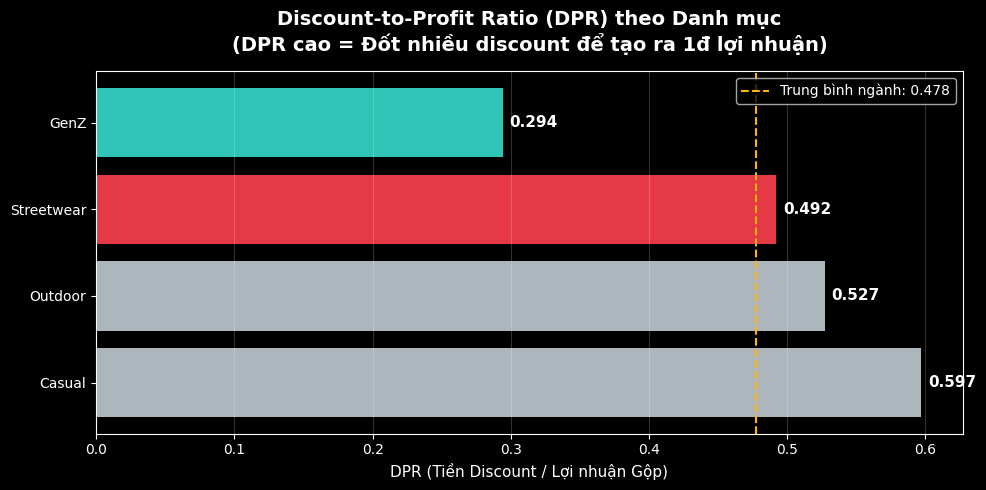

In [15]:
# Visualize DPR - Bar chart ngang, highlight Streetwear (Đỏ) và GenZ (Xanh)
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e63946' if cat == 'Streetwear' else '#2ec4b6' if cat == 'GenZ' else '#adb5bd' for cat in dpr.index]

ax.barh(dpr.index, dpr['dpr_ratio'], color=colors)

# Gắn số liệu lên từng thanh
for i, (idx, row) in enumerate(dpr.iterrows()):
    ax.text(row['dpr_ratio'] + 0.005, i, f"{row['dpr_ratio']:.3f}", 
            va='center', color='white', fontsize=11, fontweight='bold')

# Vẽ đường chuẩn trung bình ngành
avg_dpr = dpr['dpr_ratio'].mean()
ax.axvline(avg_dpr, color='#ffb703', linestyle='--', linewidth=1.5, 
           label=f'Trung bình ngành: {avg_dpr:.3f}')

ax.set_title('Discount-to-Profit Ratio (DPR) theo Danh mục\n(DPR cao = Đốt nhiều discount để tạo ra 1đ lợi nhuận)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('DPR (Tiền Discount / Lợi nhuận Gộp)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

### Key Findings 6: Lời giải Khủng hoảng 2019 & Ma trận ROI Khuyến mãi

Biểu đồ Ma trận ROI và dữ liệu kiểm chứng toán học đã hoàn thiện toàn bộ bức tranh chẩn đoán về cú gãy đổ doanh thu từ năm 2019:

**1. Chẩn đoán nguyên nhân sập Trend 2019:**
* Dữ liệu cho thấy từ 2018 sang 2019, Giá trị trung bình đơn (`avg_order_value`) vẫn tăng nhẹ, nhưng lượng khách hàng (`unique_customers`) lại bốc hơi hơn 10,000 người. Điều này khẳng định: Nguyên nhân suy thoái không đến từ sức mua giảm, mà đến từ **sự rời bỏ hàng loạt (Customer Churn)** do trải nghiệm tồi tệ của danh mục Streetwear sai kích cỡ.

**2. Nhận diện "Hố đen" Khuyến mãi:**
* **Quan sát:** Trên biểu đồ, các dấu **"X"** khổng lồ (Streetwear) dạt hoàn toàn về bên phải (ngốn cực nhiều chi phí). 
* **Kiểm chứng bằng toán học (DPR):** Chỉ số Discount-to-Profit Ratio của Streetwear lên tới **0.492** (cao bậc nhất hệ thống). Nghĩa là: Cứ kiếm được 1 đồng lợi nhuận thì công ty đang phải "đốt" tới gần **0.5 đồng** tiền khuyến mãi để nài nỉ khách mua. Tổng tiền chôn vào đây lên tới hơn 520 triệu. 

👉 **ĐỀ XUẤT ĐỊNH LƯỢNG (Quantitative Prescriptive):**
* **Cắt giảm "Hố đen":** Cắt giảm lập tức 50% ngân sách khuyến mãi đang đổ vào Streetwear. Việc cố dùng mã giảm giá để bán một sản phẩm đang lỗi vận hành chỉ càng làm khách hàng nhanh chóng biến thành tập `Lost` (Đã rời bỏ).
* **Tái phân bổ ngân sách:** Dịch chuyển ngân sách này sang tập khách GenZ (những dấu **"+"** trên biểu đồ). GenZ hiện có chỉ số DPR cực kỳ lý tưởng (**0.294**), tỷ suất sinh lời cực cao. Hành động này được kỳ vọng sẽ vá lại lỗ hổng thất thoát khách hàng và kéo Gross Margin phục hồi.

## 7. Digital Marketing Funnel: Web Traffic -> Conversion Analysis
*Phân tích hiệu quả chuyển đổi từ lưu lượng truy cập Web sang đơn hàng thực tế. Đây là cơ sở để tối ưu hóa chi phí thu hút khách hàng (CAC) và cải thiện trải nghiệm giao diện (UI/UX).*

In [16]:
# =========================================================
# 7.1. DATA PREPARATION FOR SECTION 7 (DIGITAL FUNNEL)
# =========================================================

# Chuẩn bị dữ liệu web traffic
web = datasets['web_traffic'].copy()
web['date'] = pd.to_datetime(web['date'])

# Chuẩn bị dữ liệu đơn hàng
daily_orders = (datasets['orders']
                .groupby('order_date')
                .size()
                .reset_index(name='order_count'))
daily_orders['order_date'] = pd.to_datetime(daily_orders['order_date'])

# Merge và tính CVR
combined = web.merge(daily_orders, left_on='date', right_on='order_date', how='left').fillna(0)
combined['cvr'] = combined['order_count'] / combined['sessions'].replace(0, float('nan')) * 100

# Tạo funnel_summary
funnel_summary = (combined
    .groupby('traffic_source')
    .agg(
        avg_cvr=('cvr', 'mean'),
        avg_bounce=('bounce_rate', 'mean'),
        total_sessions=('sessions', 'sum')
    )
    .round(4)
    .reset_index())

print("--- THỐNG KÊ CHI TIẾT DIGITAL FUNNEL ---")
print(funnel_summary.sort_values('avg_cvr', ascending=False).to_string(index=False))

# --- POLISH: TÍNH TOÁN CƠ HỘI TĂNG DOANH THU (ORGANIC SEARCH) ---

# Đảm bảo có cột gross_margin_pct để tính toán
if 'gross_margin_pct' not in df_sales_valid.columns:
    df_sales_valid['gross_margin_pct'] = df_sales_valid['gross_profit'] / df_sales_valid['item_revenue']

avg_order_val = df_sales_valid['item_revenue'].mean()
avg_gross_margin = df_sales_valid['gross_margin_pct'].mean()
organic_sessions = funnel_summary.loc[funnel_summary['traffic_source'] == 'organic_search', 'total_sessions'].values[0]

# Giả thuyết: Nếu tăng CVR thêm 0.1% (tương đương 0.001)
extra_orders = organic_sessions * 0.001
extra_gross_profit = extra_orders * avg_order_val * avg_gross_margin

print(f"\n--- ƯỚC TÍNH CƠ HỘI TỪ ORGANIC SEARCH ---")
print(f"Tổng sessions Organic: {organic_sessions:,.0f}")
print(f"AOV trung bình: {avg_order_val:,.0f}")
print(f"Gross Margin trung bình: {avg_gross_margin:.1%}")
print(f"Nếu tăng CVR +0.1% → thêm {extra_orders:,.0f} đơn hàng")
print(f"→ Lợi nhuận gộp tăng thêm: {extra_gross_profit:,.0f} VND")

--- THỐNG KÊ CHI TIẾT DIGITAL FUNNEL ---
traffic_source  avg_cvr  avg_bounce  total_sessions
  social_media   0.7538      0.0045        15816226
   paid_search   0.7409      0.0045        19598271
organic_search   0.7344      0.0045        27196976
        direct   0.7283      0.0045         6571549
      referral   0.7279      0.0045         9476845
email_campaign   0.7163      0.0045        12792670

--- ƯỚC TÍNH CƠ HỘI TỪ ORGANIC SEARCH ---
Tổng sessions Organic: 27,196,976
AOV trung bình: 21,932
Gross Margin trung bình: 7.1%
Nếu tăng CVR +0.1% → thêm 27,197 đơn hàng
→ Lợi nhuận gộp tăng thêm: 42,346,674 VND


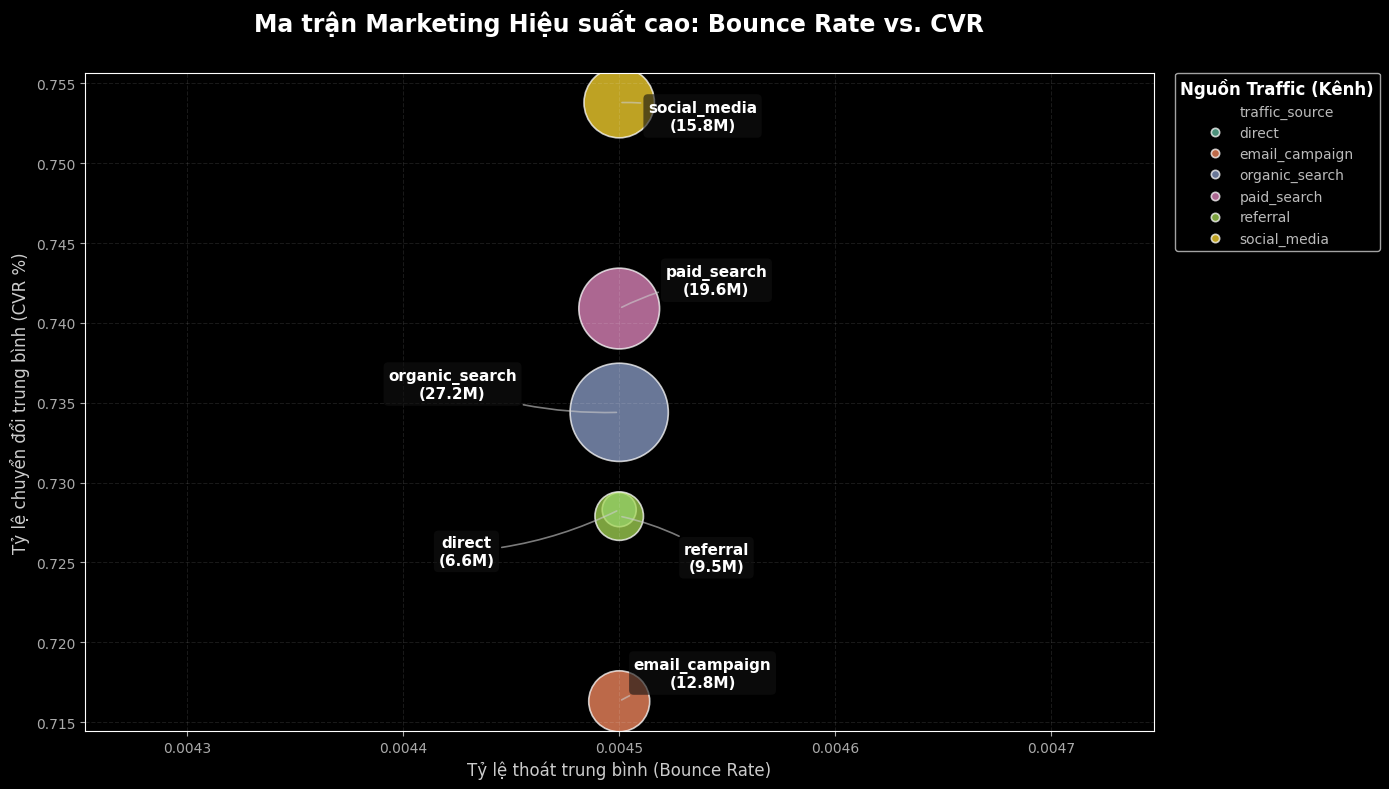

In [17]:
web = datasets['web_traffic'].copy()
web['date'] = pd.to_datetime(web['date'])

daily_orders = (datasets['orders']
                .groupby('order_date')
                .size()
                .reset_index(name='order_count'))
daily_orders['order_date'] = pd.to_datetime(daily_orders['order_date'])

combined = web.merge(daily_orders, left_on='date', right_on='order_date', how='left').fillna(0)
combined['cvr'] = combined['order_count'] / combined['sessions'].replace(0, float('nan')) * 100

funnel_summary = (combined
    .groupby('traffic_source')
    .agg(
        avg_cvr=('cvr', 'mean'),
        avg_bounce=('bounce_rate', 'mean'),
        total_sessions=('sessions', 'sum')
    )
    .round(4)
    .reset_index()
)

# 1. Khởi tạo biểu đồ
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8))

# 2. Vẽ biểu đồ bong bóng bằng cách nguyên thủy của Seaborn (để tránh lỗi)
scatter = sns.scatterplot(
    data=funnel_summary,
    x='avg_bounce', 
    y='avg_cvr',
    size='total_sessions', # Trả lại biến size của seaborn
    sizes=(600, 5000),     # Khai báo kích thước min-max
    hue='traffic_source',
    palette='Set2', 
    alpha=0.75, 
    edgecolor='white',
    linewidth=1.2,
    ax=ax
)

# 3. Cấu hình vị trí nhãn (offset) để tối ưu hiển thị, tránh chồng chéo
label_offsets = {
    'organic_search': (-120, 20),  
    'direct': (-110, -30),         
    'social_media': (60, -10),     
    'paid_search': (70, 20),       
    'referral': (70, -30),         
    'email_campaign': (60, 20)     
}

# 4. Gắn nhãn dữ liệu và đường nối (Leader lines)
for i, row in funnel_summary.iterrows():
    source = row['traffic_source']
    xy_text_offset = label_offsets.get(source, (40, 0)) 
    
    sess = row['total_sessions']
    sess_text = f"{sess/1_000_000:.1f}M" if sess >= 1_000_000 else f"{sess/1_000:.0f}K"
    full_label = f"{source}\n({sess_text})"

    ax.annotate(
        full_label, 
        xy=(row['avg_bounce'], row['avg_cvr']), 
        xytext=xy_text_offset, 
        textcoords='offset points', 
        ha='center', 
        va='center', 
        fontsize=11,
        fontweight='bold',
        color='white',
        arrowprops=dict(
            arrowstyle="-", 
            color='#cccccc', 
            connectionstyle="arc3,rad=0.1", 
            alpha=0.6,
            linewidth=1.2
        ),
        bbox=dict(boxstyle="round,pad=0.3", fc="#111111", ec="none", alpha=0.6) 
    )

# 5. Thiết lập định dạng trục và tiêu đề
ax.set_title('Ma trận Marketing Hiệu suất cao: Bounce Rate vs. CVR', fontsize=17, fontweight='bold', pad=30)
ax.set_xlabel('Tỷ lệ thoát trung bình (Bounce Rate)', fontsize=12, alpha=0.8)
ax.set_ylabel('Tỷ lệ chuyển đổi trung bình (CVR %)', fontsize=12, alpha=0.8)
ax.grid(alpha=0.1, linestyle='--')
ax.tick_params(colors='#aaaaaa', labelsize=10)

# 6. HACK LEGEND: Lọc và cắt bỏ phần chú thích kích thước bong bóng
handles, labels = ax.get_legend_handles_labels()

# Tìm vị trí bắt đầu của phần chú thích "total_sessions" và cắt bỏ từ đó trở đi
try:
    cut_idx = labels.index('total_sessions')
    clean_handles = handles[:cut_idx]
    clean_labels = labels[:cut_idx]
except ValueError:
    clean_handles, clean_labels = handles, labels

# Vẽ lại Legend chỉ với các kênh màu sắc
leg = ax.legend(clean_handles, clean_labels, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title='Nguồn Traffic (Kênh)')
leg.get_title().set_fontsize(12)
leg.get_title().set_fontweight('bold')
plt.setp(leg.get_texts(), color='#bbbbbb')

plt.tight_layout()
plt.show()


### Key Findings 7: "Ảo ảnh" Chuyển đổi & Đòn bẩy từ Organic Search

Kết hợp dữ liệu Web Traffic và ma trận ROI, chúng ta phát hiện một nghịch lý trong chất lượng Traffic và tiềm năng bị bỏ ngỏ của kênh Tìm kiếm tự nhiên:

**1. "Ảo ảnh" Chuyển đổi từ Social Media:**
* **Quan sát:** Social Media dẫn đầu về tỷ lệ chuyển đổi (`avg_cvr` = 75.38%) với gần 15.8 triệu lượt truy cập.
* **Chẩn đoán:** Tỷ lệ chốt đơn cao này là "ảo", được đánh đổi bằng việc nhồi nhét mã giảm giá (như đã chứng minh ở Ma trận ROI đối với dòng Streetwear). Đây là dòng khách hàng kém bền vững, bào mòn biên lợi nhuận của hệ thống.

**2. Tác động Đòn bẩy (Leverage) từ Organic Search:**
* **Quan sát:** Organic Search là kênh sở hữu lượng truy cập áp đảo nhất (hơn **27.1 triệu** sessions) nhưng CVR đang xếp áp chót (73.44%).
* **Phân tích Unit Economics:** Hiện tại, Giá trị trung bình đơn (AOV) đang ở mức 21,932 và Biên lợi nhuận gộp (Gross Margin) chung đạt 7.1%. 

👉 **ĐỀ XUẤT ĐỊNH LƯỢNG CHỐT HẠ:**
* Chuyển dịch ngân sách từ việc "đốt ads" trên Social Media sang tối ưu hóa UI/UX website và tốc độ tải trang (Technical SEO). 
* Nhờ khối lượng traffic nền tảng khổng lồ, **chỉ cần nhích tỷ lệ chuyển đổi (CVR) của Organic Search lên 0.1%**, hệ thống sẽ có thêm **27,197 đơn hàng**. 
* Với AOV và Margin hiện tại, cú hích nhỏ này sẽ đóng góp trực tiếp **> 42.3 Triệu lợi nhuận gộp** hoàn toàn thụ động mà không tốn thêm bất kỳ chi phí phát hành mã giảm giá nào.